In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'bird.png'

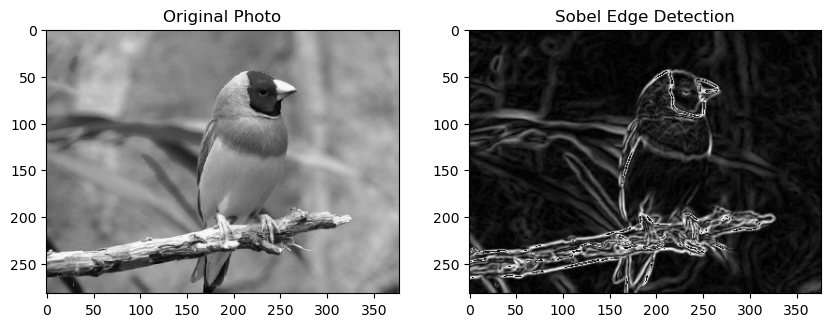

In [4]:
#Task1

img = cv2.imread(imgFile)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

sobel_combined = cv2.magnitude(sobelx, sobely)

sobel_final = np.uint8(np.absolute(sobel_combined))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Photo')
plt.subplot(1, 2, 2), plt.imshow(sobel_final, cmap='gray'), plt.title('Sobel Edge Detection')
plt.show()

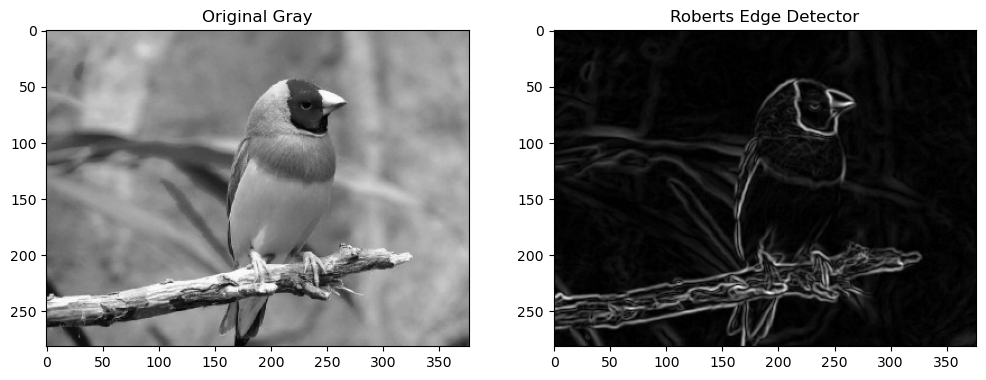

In [5]:
#Task2

image = cv2.imread(imgFile, 0)

blurred = cv2.GaussianBlur(image, (5, 5), 0)

kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float64)

roberts_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
roberts_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

roberts_combined = cv2.magnitude(roberts_x, roberts_y)

roberts_final = np.uint8(np.absolute(roberts_combined))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Gray')
plt.subplot(1, 2, 2), plt.imshow(roberts_final, cmap='gray'), plt.title('Roberts Edge Detector')
plt.show()

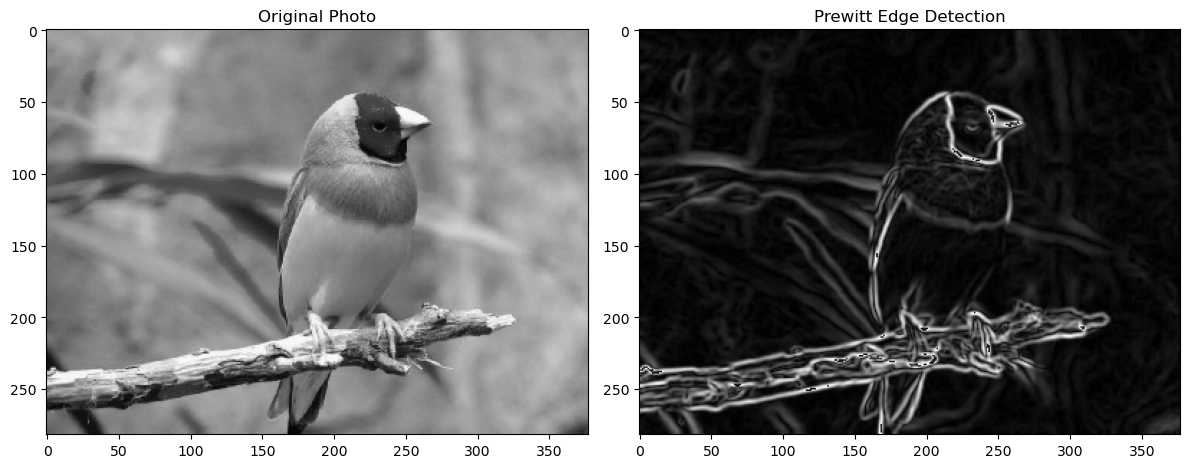

In [6]:
#Task3

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(imgFile)


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)


kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64)


prewitt_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)


prewitt_combined = cv2.magnitude(prewitt_x, prewitt_y)


prewitt_final = np.uint8(np.absolute(prewitt_combined))


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Photo')
plt.subplot(1, 2, 2), plt.imshow(prewitt_final, cmap='gray'), plt.title('Prewitt Edge Detection')
plt.tight_layout()
plt.show()

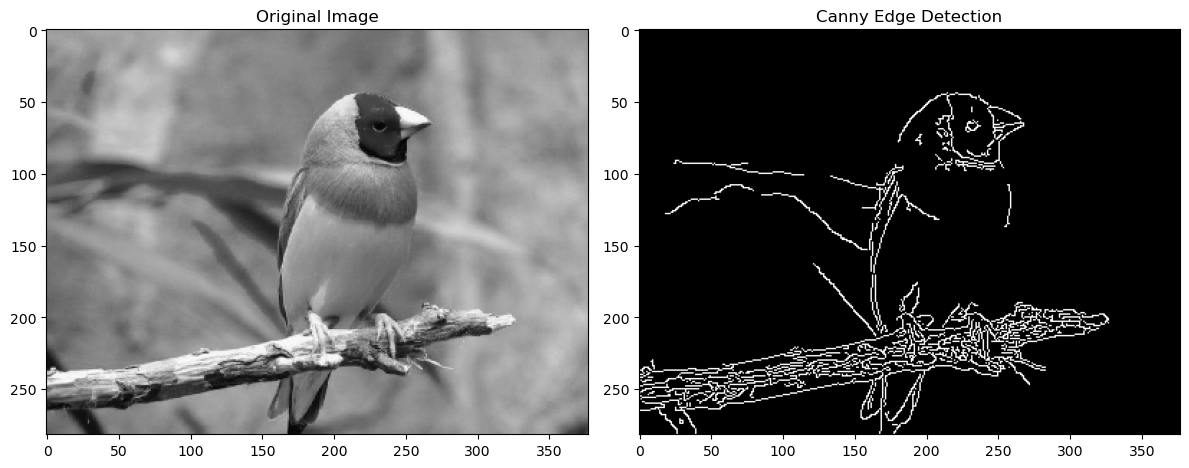

In [7]:
#Task4

import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread(imgFile)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

canny_edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(canny_edges, cmap='gray'), plt.title('Canny Edge Detection')
plt.tight_layout()
plt.show()


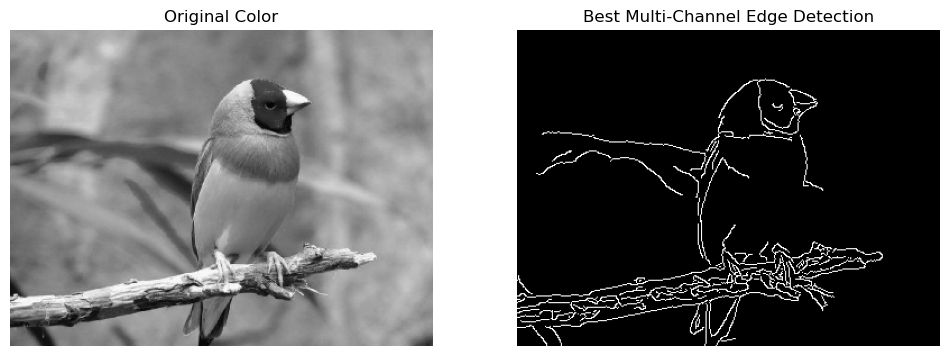

In [7]:
#Task5
def edge_detector(image_path):
    # 1. Read the image
    img = cv2.imread(image_path)

    # 2. Split into B, G, R channels
    channels = cv2.split(img)
    edge_maps = []

    for channel in channels:
        # 3. Pre-process each channel with Gaussian Blur to reduce noise
        blurred = cv2.GaussianBlur(channel, (5, 5), 0)

        # 4. Apply Canny to each channel
        # 50 and 150 are the low and high thresholds
        edges = cv2.Canny(blurred, 50, 150)
        edge_maps.append(edges)

    # 5. Merge edges from all channels using bitwise OR
    # This keeps any edge found in ANY of the three color layers
    combined_edges = cv2.bitwise_or(edge_maps[0], edge_maps[1])
    combined_edges = cv2.bitwise_or(combined_edges, edge_maps[2])

    return img, combined_edges


# Run the detector
original, edges = edge_detector(imgFile)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Color')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Best Multi-Channel Edge Detection')
plt.axis('off')

plt.show()

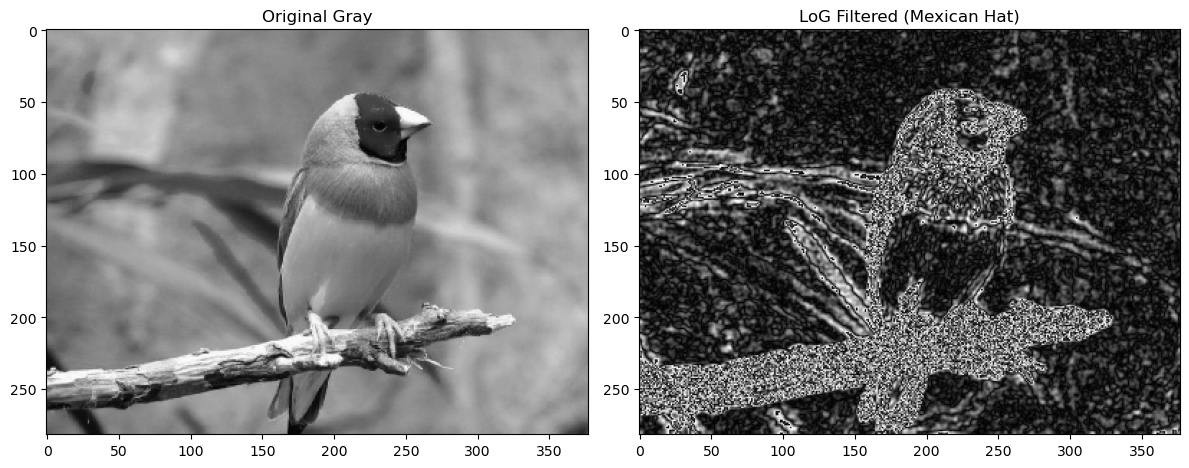

In [9]:
#Task6

# 1. Load a real-world photo in grayscale
img = cv2.imread(imgFile, cv2.IMREAD_GRAYSCALE)

# 2. Step 1: Gaussian Blur (Smoothing)
# Larger kernel/sigma reduces more noise but may miss small edges
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# 3. Step 2: Laplacian Operator (Second Derivative)
# cv2.CV_64F is used to store negative values (crucial for zero-crossings)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=5)

# 4. Post-processing: Normalize for display
# Since the Laplacian has negative and positive values, we take the absolute value
log_final = np.uint8(np.absolute(laplacian))

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original Gray')
plt.subplot(1, 2, 2), plt.imshow(log_final, cmap='gray'), plt.title('LoG Filtered (Mexican Hat)')
plt.tight_layout()
plt.show()


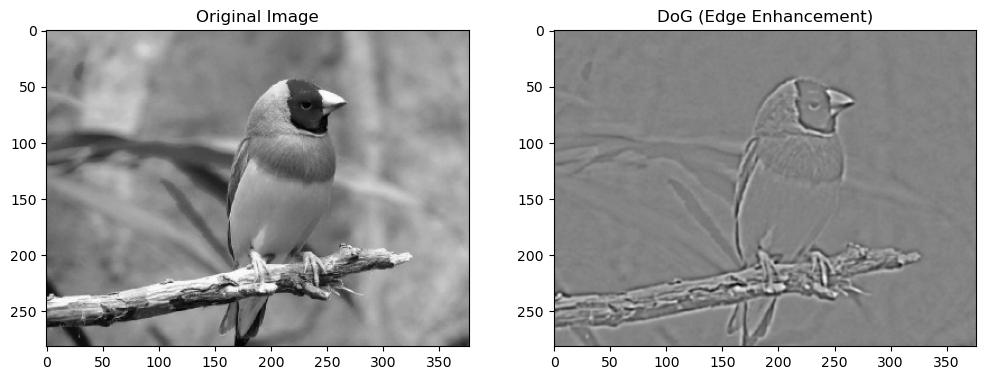

In [11]:
#Task7


# 1. Load the real-world photo
img = cv2.imread(imgFile, cv2.IMREAD_GRAYSCALE)

# 2. Apply two Gaussian blurs with different standard deviations (Sigmas)
# Low sigma preserves detail; High sigma captures broad structure
blur_narrow = cv2.GaussianBlur(img, (0, 0), sigmaX=1.0)
blur_wide = cv2.GaussianBlur(img, (0, 0), sigmaX=2.0)

# 3. Calculate the Difference (DoG)
# Note: We use float32 to avoid overflow/underflow during subtraction
dog = blur_narrow.astype(np.float32) - blur_wide.astype(np.float32)

# 4. Normalize or Threshold for visibility
# Option A: Map to 0-255 range
dog_normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Option B: Simple threshold to create a binary edge map
_, dog_binary = cv2.threshold(dog_normalized, 127, 255, cv2.THRESH_BINARY)

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(dog_normalized, cmap='gray'), plt.title('DoG (Edge Enhancement)')
plt.show()


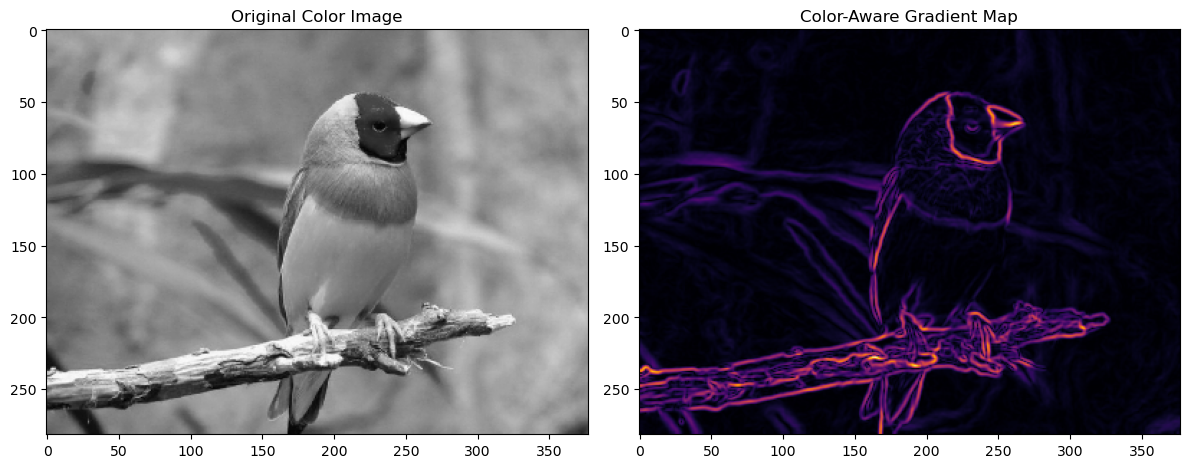

In [12]:
#Task8

# 1. Load the real-world color image
image = cv2.imread(imgFile)

# 2. Split the image into its R, G, and B components
# Note: OpenCV uses BGR order by default
b, g, r = cv2.split(image)

def get_channel_gradient(channel):
    # Use Sobel for gradient calculation on a single channel
    # Blur first to reduce noise in that specific color layer
    blurred = cv2.GaussianBlur(channel, (3, 3), 0)
    gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    return cv2.magnitude(gx, gy)

# 3. Compute gradients for each color channel
grad_b = get_channel_gradient(b)
grad_g = get_channel_gradient(g)
grad_r = get_channel_gradient(r)

# 4. Combine gradients from all channels
# This ensures edges from color-only transitions are captured
combined_gradient = np.sqrt(grad_b**2 + grad_g**2 + grad_r**2)

# 5. Normalize to 0-255 for visualization
color_edges = cv2.normalize(combined_gradient, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title('Original Color Image')
plt.subplot(1, 2, 2), plt.imshow(color_edges, cmap='inferno'), plt.title('Color-Aware Gradient Map')
plt.tight_layout()
plt.show()
